# Credit Card Approval Prediction

### An End-to-End Machine Learning Project

This notebook builds a complete machine learning pipeline that predicts whether a
credit card applicant should be **APPROVED** or **REJECTED**, based on demographic,
financial and employment information.

**Datasets used:**
- `application_record.csv` — applicant demographic & financial information
- `credit_record.csv` — historical monthly credit/loan repayment behaviour

**Workflow:**
1. Data Loading & Inspection
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing & Feature Engineering
4. Model Training & Comparison
5. Model Selection & Saving
6. Conclusion


## Epic 1 — Import Libraries, Load Dataset & Inspect

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

pd.set_option('display.max_columns', None)


In [2]:
# Load the two source datasets
application_df = pd.read_csv('../data/application_record.csv')
credit_df = pd.read_csv('../data/credit_record.csv')

print("Application record loaded:", application_df.shape)
print("Credit record loaded:", credit_df.shape)


Application record loaded: (438557, 18)
Credit record loaded: (1048575, 3)


### Dataset Shape

In [3]:
print("Application Record Shape:", application_df.shape)
print("Credit Record Shape:", credit_df.shape)


Application Record Shape: (438557, 18)
Credit Record Shape: (1048575, 3)


### Head of Application Record

In [4]:
application_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


### Head of Credit Record

In [5]:
credit_df.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


### Info

In [6]:
application_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

In [7]:
credit_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   ID              1048575 non-null  int64
 1   MONTHS_BALANCE  1048575 non-null  int64
 2   STATUS          1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 24.0 MB


### Missing Values

In [8]:
print("Missing values in application_record.csv:")
print(application_df.isnull().sum())
print()
print("Missing values in credit_record.csv:")
print(credit_df.isnull().sum())


Missing values in application_record.csv:


ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

Missing values in credit_record.csv:
ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64


### Duplicate Values

In [9]:
print("Duplicate rows in application_record.csv:", application_df.duplicated().sum())
print("Duplicate rows in credit_record.csv:", credit_df.duplicated().sum())


Duplicate rows in application_record.csv: 0


Duplicate rows in credit_record.csv: 0


### Statistical Summary

In [10]:
application_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,438557.0,NaN,NaN,NaN,6022176.269842,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CODE_GENDER,438557,2,F,294440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,438557,2,N,275459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_REALTY,438557,2,Y,304074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CNT_CHILDREN,438557.0,NaN,NaN,NaN,0.42739,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,NaN,NaN,NaN,187524.28601,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
NAME_INCOME_TYPE,438557,5,Working,226104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_EDUCATION_TYPE,438557,5,Secondary / secondary special,301821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_FAMILY_STATUS,438557,5,Married,299828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_HOUSING_TYPE,438557,6,House / apartment,393831,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Epic 2 — Exploratory Data Analysis (EDA)

We explore the distribution of key variables to understand the applicant population
before building the model.


### Histograms of Numerical Features

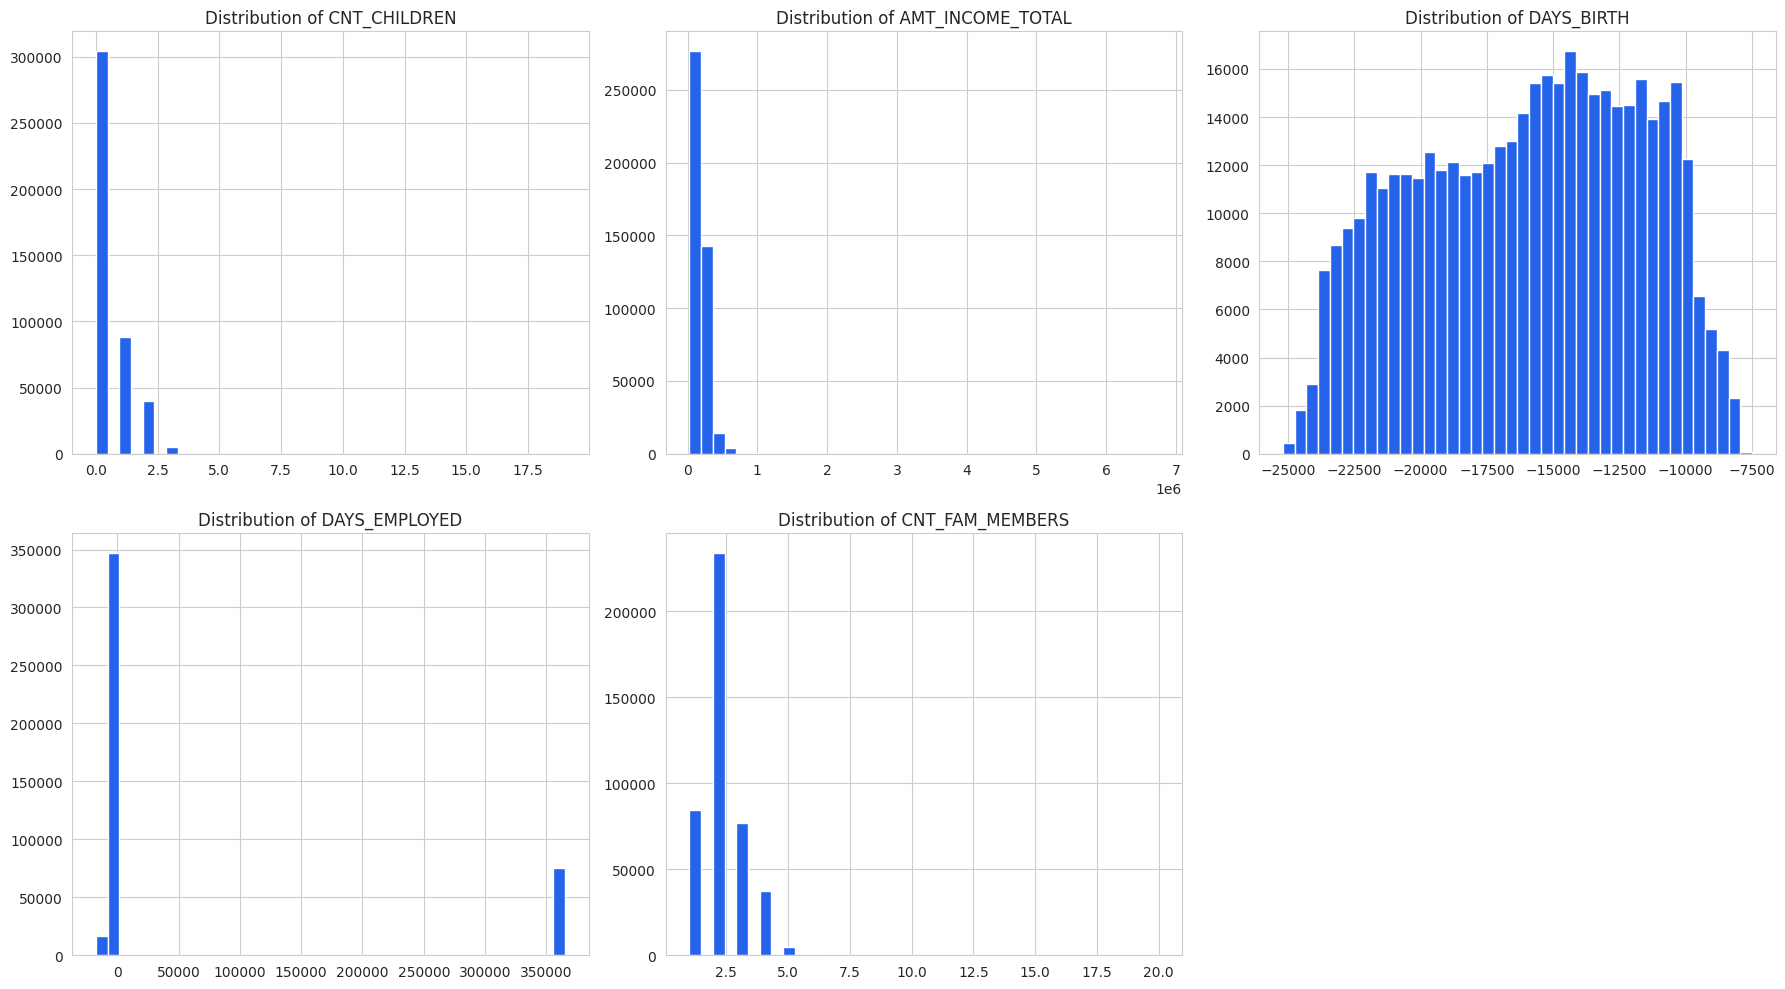

In [11]:
num_cols = ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_FAM_MEMBERS']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(application_df[col], bins=40, color='#2563eb', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()


### Countplots of Categorical Features

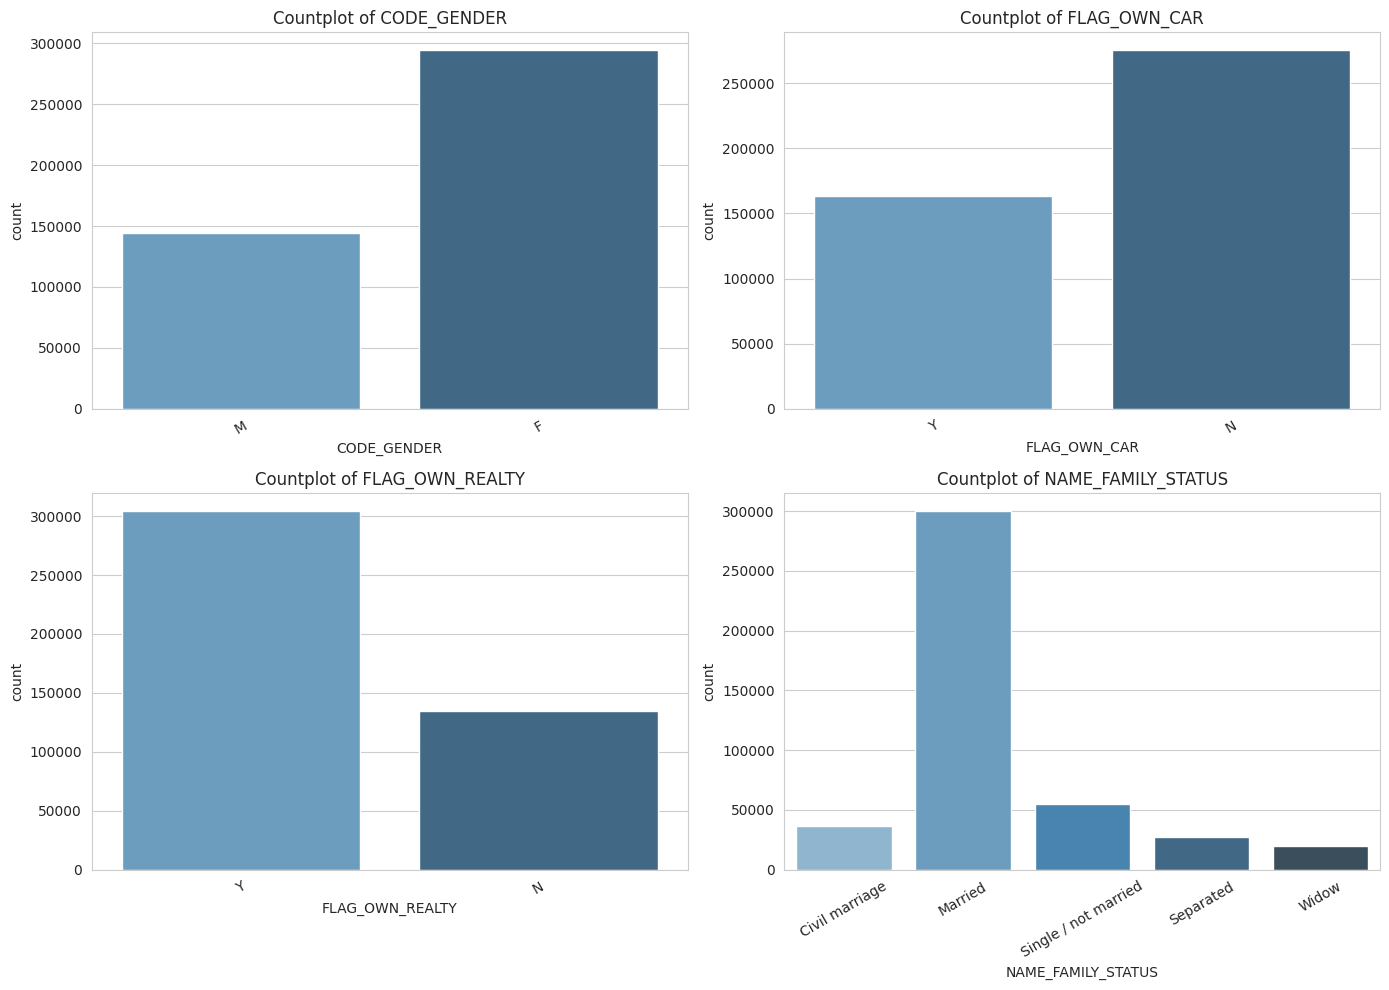

In [12]:
cat_cols = ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_FAMILY_STATUS']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=application_df, ax=axes[i], palette='Blues_d')
    axes[i].set_title(f'Countplot of {col}')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


### Income Distribution

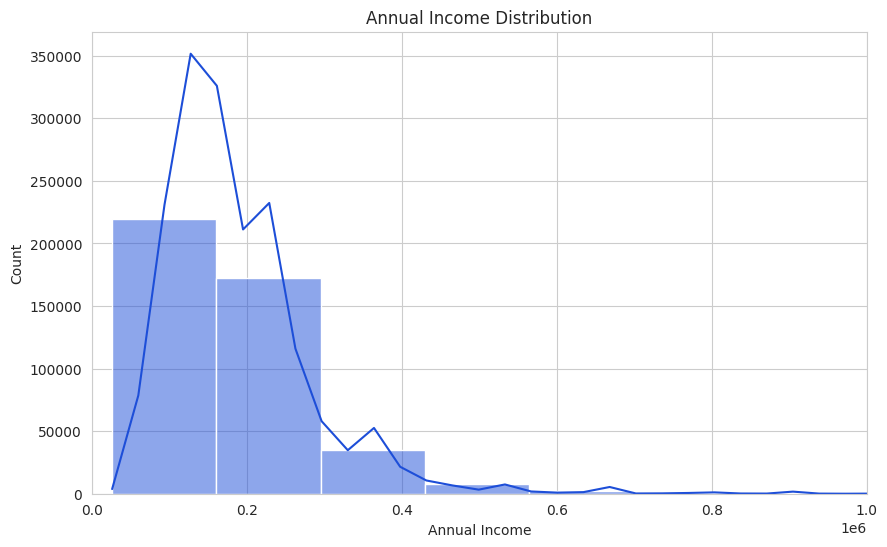

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(application_df['AMT_INCOME_TOTAL'], bins=50, kde=True, color='#1d4ed8')
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income')
plt.xlim(0, 1_000_000)
plt.show()


### Gender Distribution

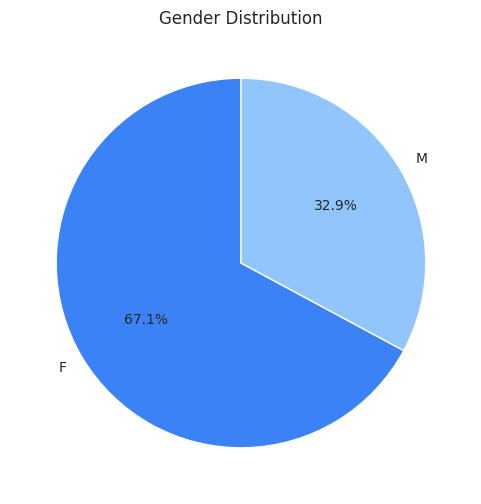

In [14]:
plt.figure(figsize=(6, 6))
application_df['CODE_GENDER'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=['#3b82f6', '#93c5fd'], startangle=90)
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()


### Education Distribution

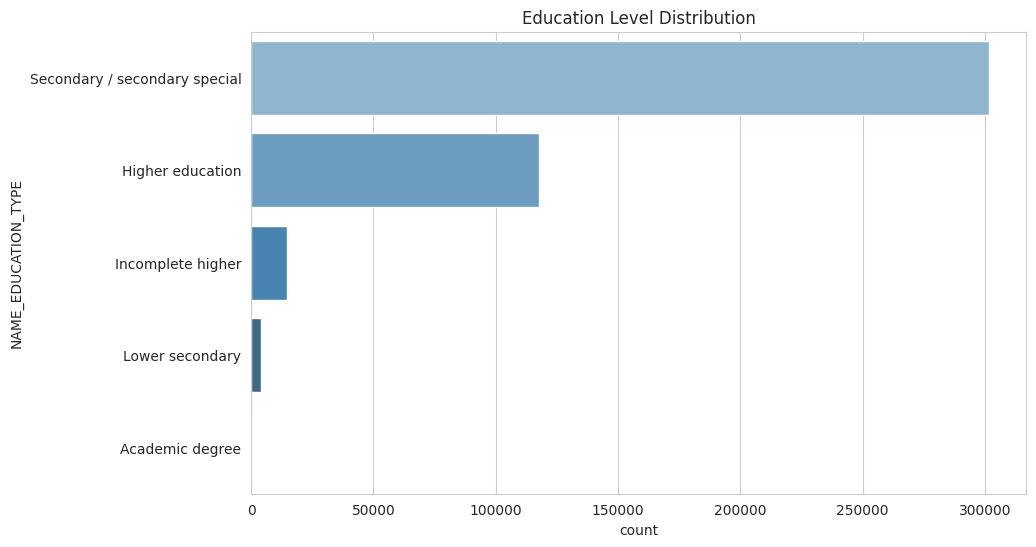

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(y='NAME_EDUCATION_TYPE', data=application_df,
              order=application_df['NAME_EDUCATION_TYPE'].value_counts().index,
              palette='Blues_d')
plt.title('Education Level Distribution')
plt.show()


### Housing Distribution

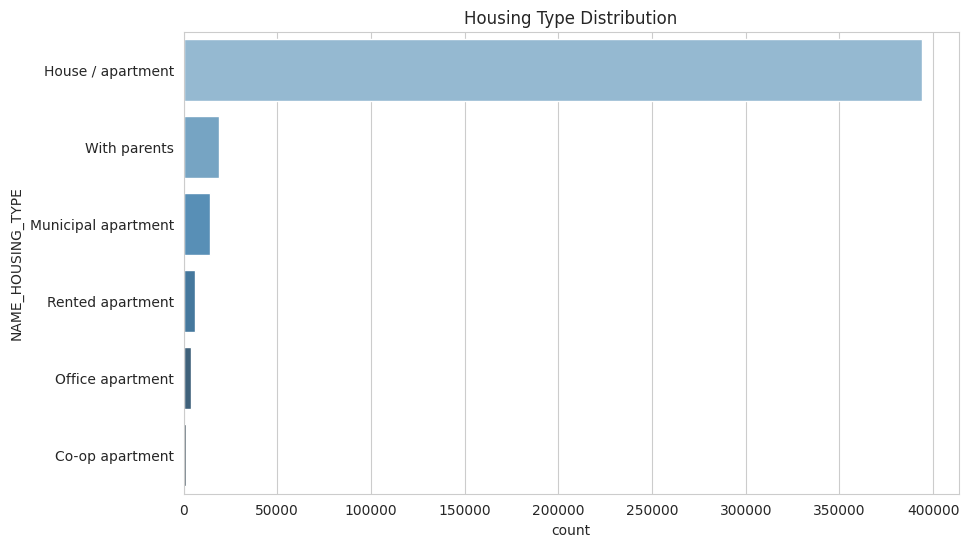

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(y='NAME_HOUSING_TYPE', data=application_df,
              order=application_df['NAME_HOUSING_TYPE'].value_counts().index,
              palette='Blues_d')
plt.title('Housing Type Distribution')
plt.show()


### Occupation Distribution

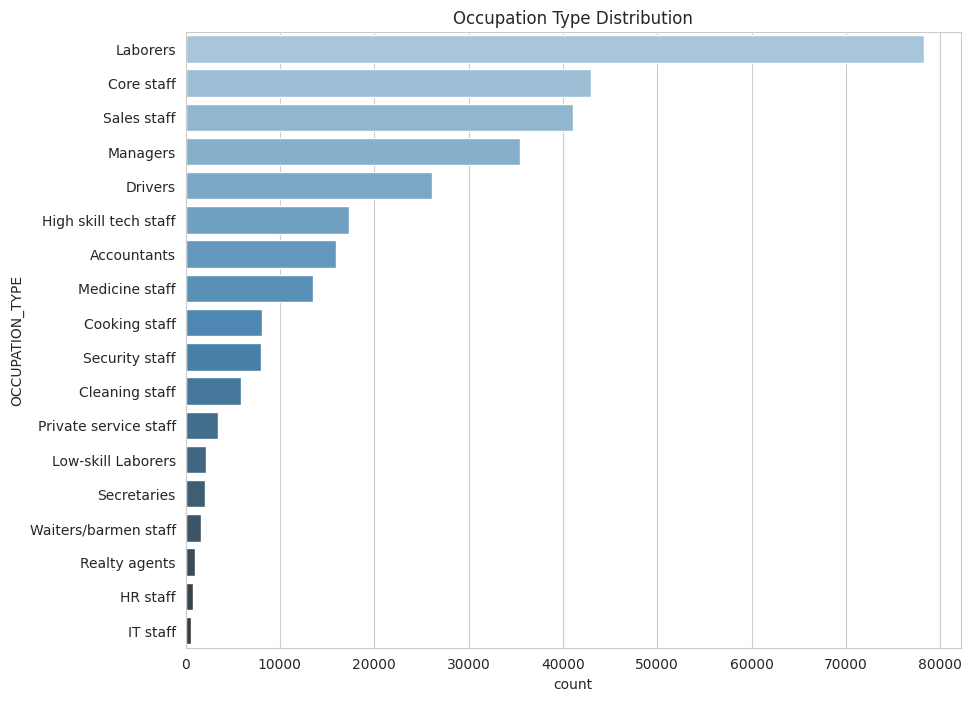

In [17]:
plt.figure(figsize=(10, 8))
sns.countplot(y='OCCUPATION_TYPE', data=application_df,
              order=application_df['OCCUPATION_TYPE'].value_counts().index,
              palette='Blues_d')
plt.title('Occupation Type Distribution')
plt.show()


### Correlation Heatmap

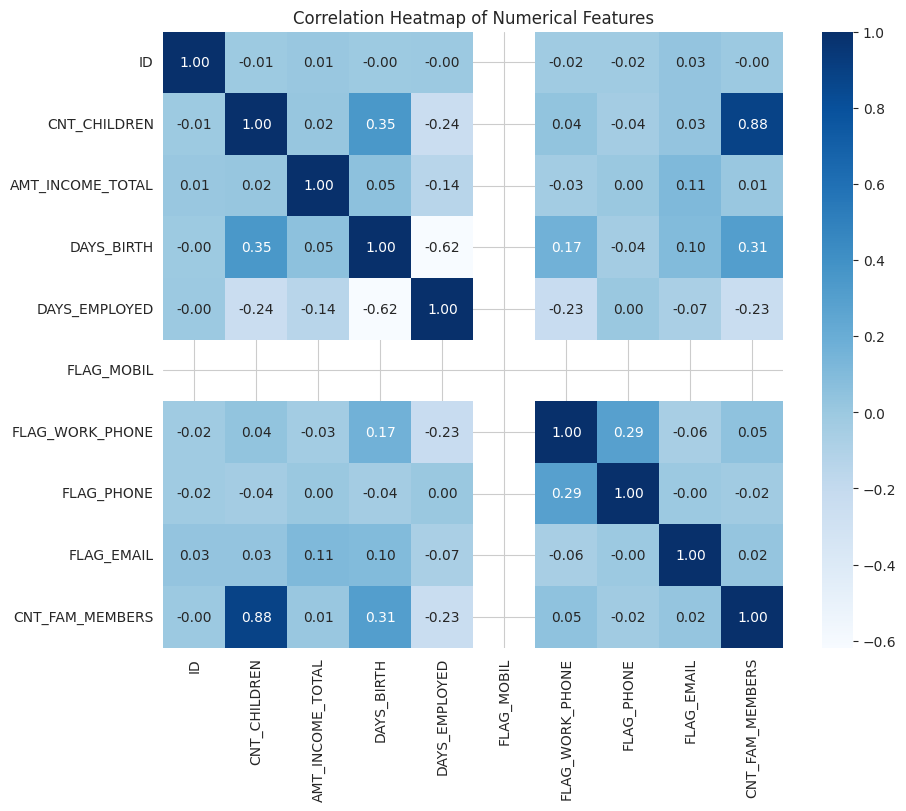

In [18]:
plt.figure(figsize=(10, 8))
numeric_df = application_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


## Epic 3 — Data Preprocessing

### Creating the TARGET variable

The `credit_record.csv` file contains a `STATUS` column with the following meaning:

| STATUS | Meaning |
|--------|---------|
| 0 | 1–29 days past due |
| 1 | 30–59 days past due |
| 2 | 60–89 days past due |
| 3 | 90–119 days past due |
| 4 | 120–149 days past due |
| 5 | Overdue / written off (bad debt) |
| C | Paid off that month |
| X | No loan for that month |

A client is labeled a **bad client (TARGET = 1, should be REJECTED)** if they have
**ever** had a status of 2, 3, 4 or 5 (60+ days past due). Otherwise they are a
**good client (TARGET = 0, should be APPROVED)**.


In [19]:
def status_to_risk(status):
    if status in ['2', '3', '4', '5']:
        return 1  # bad / risky client
    return 0  # good client

credit_df['RISK'] = credit_df['STATUS'].apply(status_to_risk)

# Aggregate to one row per client - if the client was EVER risky, they are bad
target_df = credit_df.groupby('ID')['RISK'].max().reset_index()
target_df.rename(columns={'RISK': 'TARGET'}, inplace=True)

target_df['TARGET'].value_counts()


TARGET
0    45318
1      667
Name: count, dtype: int64

### Merge Datasets

In [20]:
df = pd.merge(application_df, target_df, on='ID', how='inner')
print("Merged dataset shape:", df.shape)
df.head()


Merged dataset shape: (36457, 19)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


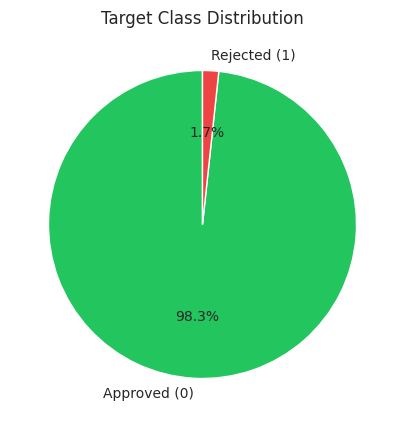

In [21]:
plt.figure(figsize=(5, 5))
df['TARGET'].value_counts().plot.pie(
    autopct='%1.1f%%', labels=['Approved (0)', 'Rejected (1)'],
    colors=['#22c55e', '#ef4444'], startangle=90)
plt.title('Target Class Distribution')
plt.ylabel('')
plt.show()


### Handle Missing Values

In [22]:
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Other')
df.isnull().sum()


ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
TARGET                 0
dtype: int64

### Feature Engineering

- **AGE**: derived from `DAYS_BIRTH` (which is negative days from today)
- **YEARS_EMPLOYED**: derived from `DAYS_EMPLOYED` (positive values mean "not currently employed" / pensioner, which we clip to 0)


In [23]:
df['AGE'] = (-df['DAYS_BIRTH'] // 365).astype(int)
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'].apply(lambda x: 0 if x > 0 else (-x // 365))

df.drop(['DAYS_BIRTH', 'DAYS_EMPLOYED'], axis=1, inplace=True)
df[['AGE', 'YEARS_EMPLOYED']].describe()


,AGE,YEARS_EMPLOYED
count,36457.000000,36457.000000
mean,43.260334,5.614560
std,11.510414,6.417027
min,20.000000,0.000000
25%,34.000000,1.000000
50%,42.000000,4.000000
75%,53.000000,8.000000
max,68.000000,43.000000


### Remove Unnecessary Columns

In [24]:
drop_cols = ['ID', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

df.drop_duplicates(inplace=True)
print("Final dataset shape after cleaning:", df.shape)
df.head()


Final dataset shape after cleaning: (9713, 14)


,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,YEARS_EMPLOYED
0,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,Other,2.0,0,32,12
2,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,Security staff,2.0,0,58,3
3,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,Sales staff,1.0,0,52,8
7,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,Other,1.0,0,61,0
10,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,Accountants,2.0,0,46,2


### Label Encoding

Every categorical column is transformed using `LabelEncoder`, and each fitted
encoder is stored in a dictionary so it can be reused later by the Flask app to
transform raw text input (e.g. `"Male"`, `"Working"`) into the numeric codes the
model expects.


In [25]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE'
]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: {list(le.classes_)}")


CODE_GENDER: ['F', 'M']
FLAG_OWN_CAR: ['N', 'Y']
FLAG_OWN_REALTY: ['N', 'Y']
NAME_INCOME_TYPE: ['Commercial associate', 'Pensioner', 'State servant', 'Student', 'Working']
NAME_EDUCATION_TYPE: ['Academic degree', 'Higher education', 'Incomplete higher', 'Lower secondary', 'Secondary / secondary special']
NAME_FAMILY_STATUS: ['Civil marriage', 'Married', 'Separated', 'Single / not married', 'Widow']
NAME_HOUSING_TYPE: ['Co-op apartment', 'House / apartment', 'Municipal apartment', 'Office apartment', 'Rented apartment', 'With parents']
OCCUPATION_TYPE: ['Accountants', 'Cleaning staff', 'Cooking staff', 'Core staff', 'Drivers', 'HR staff', 'High skill tech staff', 'IT staff', 'Laborers', 'Low-skill Laborers', 'Managers', 'Medicine staff', 'Other', 'Private service staff', 'Realty agents', 'Sales staff', 'Secretaries', 'Security staff', 'Waiters/barmen staff']


### Train / Test Split

In [26]:
from sklearn.model_selection import train_test_split

X = df.drop('TARGET', axis=1)
y = df['TARGET']

FEATURE_ORDER = list(X.columns)
print("Feature order used by the model:")
print(FEATURE_ORDER)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Feature order used by the model:
['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'AGE', 'YEARS_EMPLOYED']
Train shape: (7770, 13)
Test shape: (1943, 13)


### Feature Scaling

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Train Multiple Models

We train four classification models and compare their accuracy on the held-out
test set:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=8),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', max_depth=10, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=pos_weight)
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    trained_models[name] = model
    print(f"{name}: Accuracy = {acc:.4f}")


Logistic Regression: Accuracy = 0.5703
Decision Tree: Accuracy = 0.6722


Random Forest: Accuracy = 0.9156
XGBoost: Accuracy = 0.8986


### Compare Accuracy

In [29]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values('Accuracy', ascending=False)
results_df


,Model,Accuracy
2,Random Forest,0.915594
3,XGBoost,0.898610
1,Decision Tree,0.672156
0,Logistic Regression,0.570252


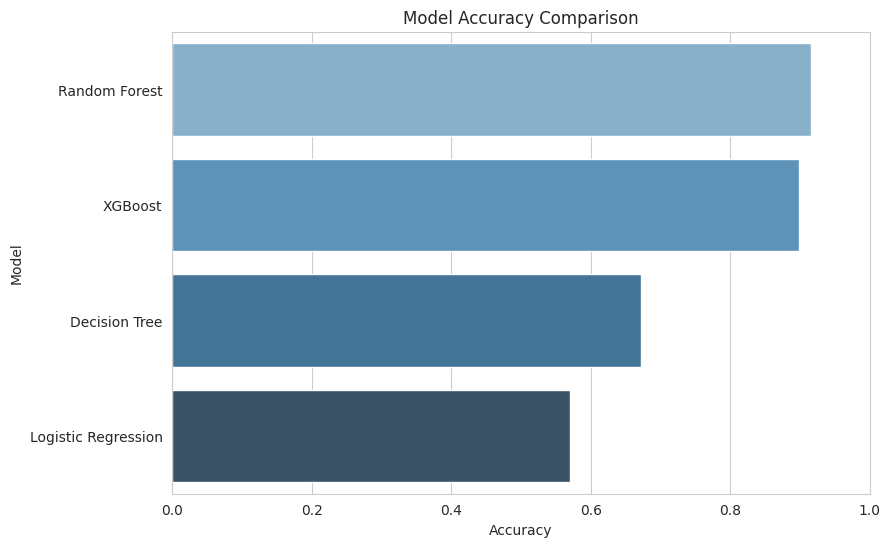

In [30]:
plt.figure(figsize=(9, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='Blues_d')
plt.title('Model Accuracy Comparison')
plt.xlim(0, 1)
plt.show()


### Select Best Model

In [31]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"Best performing model: {best_model_name} (Accuracy = {results[best_model_name]:.4f})")

preds = best_model.predict(X_test_scaled)
print()
print(classification_report(y_test, preds, target_names=['Approved', 'Rejected']))


Best performing model: Random Forest (Accuracy = 0.9156)

              precision    recall  f1-score   support

    Approved       0.96      0.95      0.96      1855
    Rejected       0.09      0.09      0.09        88

    accuracy                           0.92      1943
   macro avg       0.52      0.52      0.52      1943
weighted avg       0.92      0.92      0.92      1943



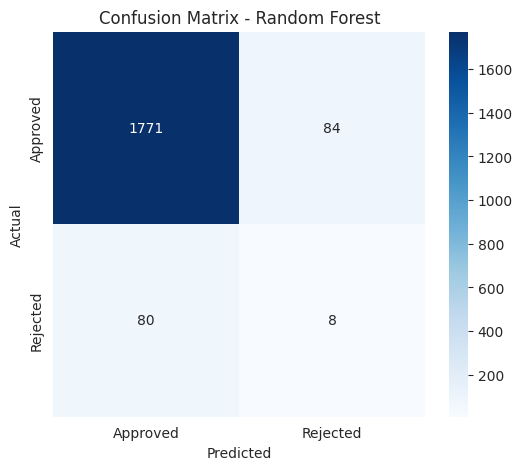

In [32]:
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Approved', 'Rejected'],
            yticklabels=['Approved', 'Rejected'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


### Save Model Artifacts

We persist the trained model, the scaler, and the label encoders so the Flask
web application can load them directly without retraining.


In [33]:
import os
os.makedirs('../model', exist_ok=True)

with open('../model/credit_card_approval_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('../model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../model/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

with open('../model/feature_order.pkl', 'wb') as f:
    pickle.dump(FEATURE_ORDER, f)

print("All artifacts saved successfully to the model/ directory:")
print("- credit_card_approval_model.pkl")
print("- scaler.pkl")
print("- label_encoders.pkl")
print("- feature_order.pkl")


All artifacts saved successfully to the model/ directory:
- credit_card_approval_model.pkl
- scaler.pkl
- label_encoders.pkl
- feature_order.pkl


## Epic 4 — Conclusion

In this notebook we built a complete, end-to-end credit card approval prediction
pipeline:

1. **Data Understanding** — loaded and inspected the application and credit
   history datasets, checked for missing values and duplicates.
2. **EDA** — visualized the distribution of income, gender, education, housing,
   and occupation to understand the applicant population.
3. **Target Engineering** — derived a binary `TARGET` label (Approved / Rejected)
   from historical repayment behaviour in `credit_record.csv`.
4. **Feature Engineering** — converted `DAYS_BIRTH` and `DAYS_EMPLOYED` into
   human-readable `AGE` and `YEARS_EMPLOYED` features.
5. **Modeling** — trained and compared Logistic Regression, Decision Tree,
   Random Forest, and XGBoost classifiers.
6. **Deployment Readiness** — saved the best model along with the scaler and
   label encoders, ready to be consumed by the Flask web application in `app.py`.

**Future improvements** could include hyperparameter tuning, handling class
imbalance with SMOTE, adding more engineered features (e.g. income-to-family-size
ratio), and exploring model explainability with SHAP.
